# **Practice 14 - JavaScript Object Notation and APIs**

#### **Kelani Guyton**

---

**IMPORTANT**:
- Before starting the lab, save a copy to your google drive by navigating to `File > Save a copy in Drive` <br>

<br>


**Instructions**: Complete the lab below.

- <font color=red>Tasks</font> indicated in red must be completed to receive credit
- Include all code for your work
- Include markdown cells with written answers explaining your work when prompted
- **NOTE: Your completed lab must be submitted to Canvas as a .ipynb file by the end of the lab session**
---

<br>

####<font color=red>Organized</font>

**Answers should be organized in the following format for organization and readability**


<font color=red>Example task 1</font>

In [ ]:
# 1.

# This will be the code block to answer the first part of a task

1. This will be the text answer/explanation (if prompted) for the first task

<font color=red>Example task 2</font>

In [ ]:
# 2.

# This will be the code block to answer the second part of a task

2. This will be the text answer/explanation (if prompted) for the second task

<br>

Continue this format for the remaining subtasks


<br>

---

<br>

#### Packages

In [1]:
# install packages
install.packages("jsonlite")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [2]:
# load libraries
library(jsonlite)

<br>

<br>

<br>

---

####<font color=red>Task 1</font>


The goal of this assignment is to visualize the use of tobacco across countries over time.

<font color=red>Task 1.1</font>

* Use the code from lecture to load the `M_Est_tob_curr_std` variable from the WHO website

* Extract the `value` list item and store as the data frame `tobacco`

* Show the `head()` of the `tobacco` data frame

In [4]:
# from lecture

# path to data
url_path <- "https://ghoapi.azureedge.net/api/"

# selected variable
variable <- "M_Est_tob_curr_std"

json_data <- fromJSON(paste0(url_path, variable))
                             # simplify data frame = FALSE # if you want it as a list, not a data frame

In [5]:
# extract the tabacco data from `json_data`
tabacco <- json_data$value

# check the first few observations
head(tabacco, 3)

,Id,IndicatorCode,SpatialDimType,SpatialDim,TimeDimType,ParentLocationCode,ParentLocation,Dim1Type,TimeDim,Dim1,⋯,DataSourceDim,Value,NumericValue,Low,High,Comments,Date,TimeDimensionValue,TimeDimensionBegin,TimeDimensionEnd
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,⋯,<lgl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,5337000,M_Est_tob_curr_std,COUNTRY,CPV,YEAR,AFR,Africa,SEX,2007,SEX_FMLE,⋯,NA,9.6 [6.7-12.5],9.6,6.7,12.5,NA,2026-01-15T18:43:44.287+01:00,2007,2007-01-01T00:00:00+01:00,2007-12-31T00:00:00+01:00
2,5340648,M_Est_tob_curr_std,COUNTRY,LBN,YEAR,EMR,Eastern Mediterranean,SEX,2020,SEX_MLE,⋯,NA,51.3 [40.7-62.0],51.3,40.7,62.0,NA,2026-01-15T18:43:44.287+01:00,2020,2020-01-01T00:00:00+01:00,2020-12-31T00:00:00+01:00
3,5340687,M_Est_tob_curr_std,COUNTRY,TUV,YEAR,WPR,Western Pacific,SEX,2010,SEX_BTSX,⋯,NA,41.1 [30.0-52.1],41.1,30.0,52.1,Tobacco use estimates are not available. Tobacco smoking estimates are substituted for missing tobacco use estimates.,2026-01-15T18:43:44.287+01:00,2010,2010-01-01T00:00:00+01:00,2010-12-31T00:00:00+01:00


<br>

<font color=red>Task 1.2</font>

* Use the `str()` function to explore the data frame

* How many columns are in the `tobacco` data frame?

* How many rows are in the `tobacco` data frame?

<br>

<br>

In [7]:
# gives dimensions of data frame
dim(tabacco)

# variable names & types
str(tabacco)

[1] 5742   25

'data.frame':	5742 obs. of  25 variables:
 $ Id                : int  5337000 5340648 5340687 5345176 5345336 5348757 5352950 5353147 5356286 5358494 ...
 $ IndicatorCode     : chr  "M_Est_tob_curr_std" "M_Est_tob_curr_std" "M_Est_tob_curr_std" "M_Est_tob_curr_std" ...
 $ SpatialDimType    : chr  "COUNTRY" "COUNTRY" "COUNTRY" "COUNTRY" ...
 $ SpatialDim        : chr  "CPV" "LBN" "TUV" "ZWE" ...
 $ TimeDimType       : chr  "YEAR" "YEAR" "YEAR" "YEAR" ...
 $ ParentLocationCode: chr  "AFR" "EMR" "WPR" "AFR" ...
 $ ParentLocation    : chr  "Africa" "Eastern Mediterranean" "Western Pacific" "Africa" ...
 $ Dim1Type          : chr  "SEX" "SEX" "SEX" "SEX" ...
 $ TimeDim           : int  2007 2020 2010 2030 2024 2025 2010 2015 2022 2024 ...
 $ Dim1              : chr  "SEX_FMLE" "SEX_MLE" "SEX_BTSX" "SEX_MLE" ...
 $ Dim2Type          : logi  NA NA NA NA NA NA ...
 $ Dim2              : logi  NA NA NA NA NA NA ...
 $ Dim3Type          : logi  NA NA NA NA NA NA ...
 $ Dim3              : logi  

There are 5,742 rows / observations and 25 columns / variables.

<br>

---

####<font color=red>Task 2</font>


Our data is quite a mess! We have rows and columns we don't need. Let's "clean" our dataset.

<font color=red>Task 2.1</font>

* What are the unique values of the `SpatialDimType` variable? You can use the `unique()` function.

* What are the unique values of the `Dim1` variable? Note that this variable represents male, female, or both (overall)

* What is the range of years in the dataset based on the `TimeDim` variable?

* What is the most recent year of data as indicated by the `TimeDim` variable?

In [10]:
# unique values in `SpatialDimType`
unique(tabacco$SpatialDimType)

[1] "COUNTRY" "REGION"  "GLOBAL"

the unique values for the `SpatialDimType` variable are `COUNTRY`, `REGION`, and `GLOBAL`.

In [11]:
# unique values of `Dim1`
unique(tabacco$Dim1)

[1] "SEX_FMLE" "SEX_MLE"  "SEX_BTSX"

The unique values for `Dim1` are `SEX_FMLE`, `SEX_MLE`, and `SEX_BTSX`.

In [14]:
# range if years based on `TimeDim`
range(tabacco$TimeDim)
min(tabacco$TimeDim)

# also most recent year
max(tabacco$TimeDim)

[1] 2000 2030

[1] 2000

[1] 2030

the range of years based on the `TimeDim` variable are 2000 to 2030. The most recent year is 2030.

<br>

<font color=red>Task 2.2</font> Since we are interested in visualizing the use of tobacco across countries over time, we need to perform some subsetting

* Subset the dataset to only include countries

* Subset the dataset to only include rows corresponding to both sexes (overall, not just female or male)

* Subset the dataset to only include years prior to (less than 2025)

  You may store the resulting data frame as `tobacco2`.
  
  Hint: You should have 1,320 rows

In [15]:
tabacco2 <- tabacco[tabacco$SpatialDimType == "COUNTRY" &
                    tabacco$Dim1 == "SEX_BTSX" &
                    tabacco$TimeDim < 2025, ]      # data[rows, columns]

# check number of rows
nrow(tabacco2)

# check the first few observations
head(tabacco2, 3)

[1] 1503

,Id,IndicatorCode,SpatialDimType,SpatialDim,TimeDimType,ParentLocationCode,ParentLocation,Dim1Type,TimeDim,Dim1,⋯,DataSourceDim,Value,NumericValue,Low,High,Comments,Date,TimeDimensionValue,TimeDimensionBegin,TimeDimensionEnd
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,⋯,<lgl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
3,5340687,M_Est_tob_curr_std,COUNTRY,TUV,YEAR,WPR,Western Pacific,SEX,2010,SEX_BTSX,⋯,NA,41.1 [30.0-52.1],41.1,30.0,52.1,Tobacco use estimates are not available. Tobacco smoking estimates are substituted for missing tobacco use estimates.,2026-01-15T18:43:44.287+01:00,2010,2010-01-01T00:00:00+01:00,2010-12-31T00:00:00+01:00
7,5352950,M_Est_tob_curr_std,COUNTRY,THA,YEAR,SEAR,South-East Asia,SEX,2010,SEX_BTSX,⋯,NA,22.6 [19.1-26.1],22.6,19.1,26.1,Tobacco use estimates are not available. Tobacco smoking estimates are substituted for missing tobacco use estimates.,2026-01-15T18:43:44.287+01:00,2010,2010-01-01T00:00:00+01:00,2010-12-31T00:00:00+01:00
8,5353147,M_Est_tob_curr_std,COUNTRY,TZA,YEAR,AFR,Africa,SEX,2015,SEX_BTSX,⋯,NA,12.6 [10.3-15.0],12.6,10.3,15.0,NA,2026-01-15T18:43:44.287+01:00,2015,2015-01-01T00:00:00+01:00,2015-12-31T00:00:00+01:00


<br>

<font color=red>Task 2.3</font> We don't need most of these columns!

* Create a new data frame called `tobacco_clean` from `tobacco2` (Task 2.2) that only includes the following variables
  * `SpatialDim`
  * `TimeDim`
  * `NumericValue`

* Rename these columns to
  * `country`
  * `year`
  * `prevalence`

In [16]:
tabacco_clean <- tabacco2[, c("SpatialDim", "TimeDim", "NumericValue")]   # data[rows, columns]

# check first few observations
head(tabacco_clean)

,SpatialDim,TimeDim,NumericValue
,<chr>,<int>,<dbl>
3,TUV,2010,41.1
7,THA,2010,22.6
8,TZA,2015,12.6
10,MMR,2024,43.4
13,BLR,2015,33.7
21,ESP,2022,28.1


In [17]:
# rename variable names
names(tabacco_clean) <- c("Country", "year", "prevalence")

# check
head(tabacco_clean)

,Country,year,prevalence
,<chr>,<int>,<dbl>
3,TUV,2010,41.1
7,THA,2010,22.6
8,TZA,2015,12.6
10,MMR,2024,43.4
13,BLR,2015,33.7
21,ESP,2022,28.1


<br>

<br>

<br>

---

####<font color=red>Task 3</font>


<font color=red>Task 3.1</font>

* Using the `tobacco_clean` data frame, plot a boxplot with `prevalence` on the y-axis and `year` on the x-axis
  
  Hint: `boxplot(y ~ x)`

  Although `year` is a numeric data type, the `boxplot()` function automatically converts the variable to a `factor`.


* In a text cell, write your observations from the plot

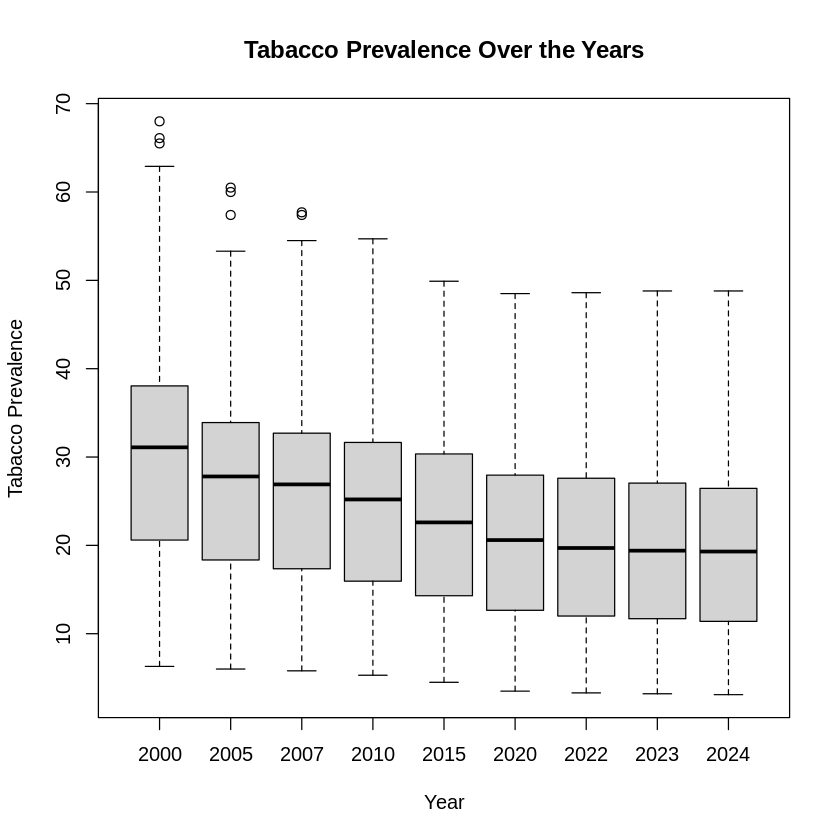

In [19]:
# make boxplot
boxplot(tabacco_clean$prevalence ~ tabacco_clean$year,
        xlab = "Year",
        ylab = "Tabacco Prevalence",
        main = "Tabacco Prevalence Over the Years")
?boxplot()

It appears that tabacco prevalence is decreasing over time.

<br>

<font color=red>Task 3.2</font>

Use `R` code to answer the following questions

* Which country had the highest tobacco prevalence in 2022?

* Which country had the lowest tobacco prevalence in 2022?

* What was the prevalence for `USA` in 2022?

Note that the countries in the dataset are abbreviations. Feel free to search online for the actual country name!

In [21]:
# subset for 2022
tabacco_2022 <- tabacco_clean[tabacco_clean$year == 2022, ]

# find the index of the maximum
index_of_max <- which.max(tabacco_2022$prevalence)

# extract the corresponding row of the max
tabacco_2022[index_of_max, ]

# find the index of the minimum
index_of_min <- which.min(tabacco_2022$prevalence)

# extract the corresponding row of the minimum
tabacco_2022[index_of_min, ]

,Country,year,prevalence
,<chr>,<int>,<dbl>
3049,TLS,2022,48.6


,Country,year,prevalence
,<chr>,<int>,<dbl>
4124,NGA,2022,3.3


The country with the highest tabacco prevalence in 2022 was the Democratic Republic of Timor-Leste.

The country with the lowest tabacco prevalence in 2022 was Nigeria.

In [22]:
tabacco_2022[tabacco_2022$country == "USA", ]

Country,year,prevalence
<chr>,<int>,<dbl>


The tabacco prevalence in the USA in 2022 was 17%.

<br>

<br>

<br>

---

####<font color=red>Extra Challenge (optional)</font>


<font color=red>Task E.1</font>

* Did any country have an increase in prevalence between 2000 and 2022? If so, which countries were they?

  There are many ways to do this, but some are more efficient than others.

In [27]:
# subset the data for each year
tabacco_2000 <- tabacco_clean[tabacco_clean$year == 2000, ]
tabacco_2022 <- tabacco_clean[tabacco_clean$year == 2022, ]

# order by country
tabacco_2000 <- tabacco_2000[order(tabacco_2000$Country), ]
tabacco_2022 <- tabacco_2022[order(tabacco_2022$Country), ]

# check that all of the countries are lined up
tabacco_2000$country == tabacco_2022$Country

logical(0)

In [30]:
# subtract the prevalence store
tabacco_2022$prevalence_change <- tabacco_2022$prevalence - tabacco_2000$prevalence

# order the data so highest changes are on the top
tabacco_2022 <- tabacco_2022[order(tabacco_2022$prevalence_change, decreasing = TRUE), ]
head(tabacco_2022, 20)

,Country,year,prevalence,prevalence_change
,<chr>,<int>,<dbl>,<dbl>
5380,LBN,2022,45.6,11.3
2421,PSE,2022,34.8,7.3
44,MDA,2022,28.3,4.9
3180,EGY,2022,24.4,4.7
1649,PRT,2022,28.0,4.5
5431,COG,2022,15.5,3.8
5055,BHS,2022,17.0,3.6
1635,MHL,2022,29.6,2.2
3049,TLS,2022,48.6,1.7


There were several countries that had in increase in prevalence between the years 2000 and 2022. The countries were LBN, PSE, MDA, EGY, PRT, COG, BHS, MHL, TLS, DZ, LSO, STP, JOR, OMN, ZAF, SWZ, MNE, and SAU. The only countries that did not have prevalence were QAT and AND.